In [1]:
import numpy as np
import pandas as pd

In [2]:
lr001 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lr_0.01_results.tsv", sep="\t")
lr001["lr"] = [0.01 for i in range(len(lr001))]

In [3]:
lr01 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lr_0.1_results.tsv", sep="\t")
lr01["lr"] = [0.1 for i in range(len(lr01))]

In [4]:
lr05 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lr_0.5_results.tsv", sep="\t")
lr05["lr"] = [0.5 for i in range(len(lr05))]

In [5]:
lr10 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/control_results.tsv", sep="\t")
lr10["lr"] = [1.0 for i in range(len(lr10))]

In [6]:
lr20 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/lr_2.0_results.tsv", sep="\t")
lr20["lr"] = [2.0 for i in range(len(lr20))]

In [7]:
df = pd.concat([lr001, lr01, lr05, lr10, lr20], ignore_index=True)

In [8]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [9]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'best_output_loss',
       'num_edits', 'best_PearsonR', 'SCD', 'URQ_result', 'URQ_target',
       'URQ_init', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'lr',
       'URQ_diff'],
      dtype='object')

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

/tmp/SLURM_1063880/ipykernel_213892/311516068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lr', y=metric, ax=ax, palette="Set2", order=lr_order)
/tmp/SLURM_1063880/ipykernel_213892/311516068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lr', y=metric, ax=ax, palette="Set2", order=lr_order)
/tmp/SLURM_1063880/ipykernel_213892/311516068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lr', y=metric, ax=ax, palette="Set2", order=lr_order)
/tmp/SLURM_1063880/ipykernel_213892/311516068.py:24:

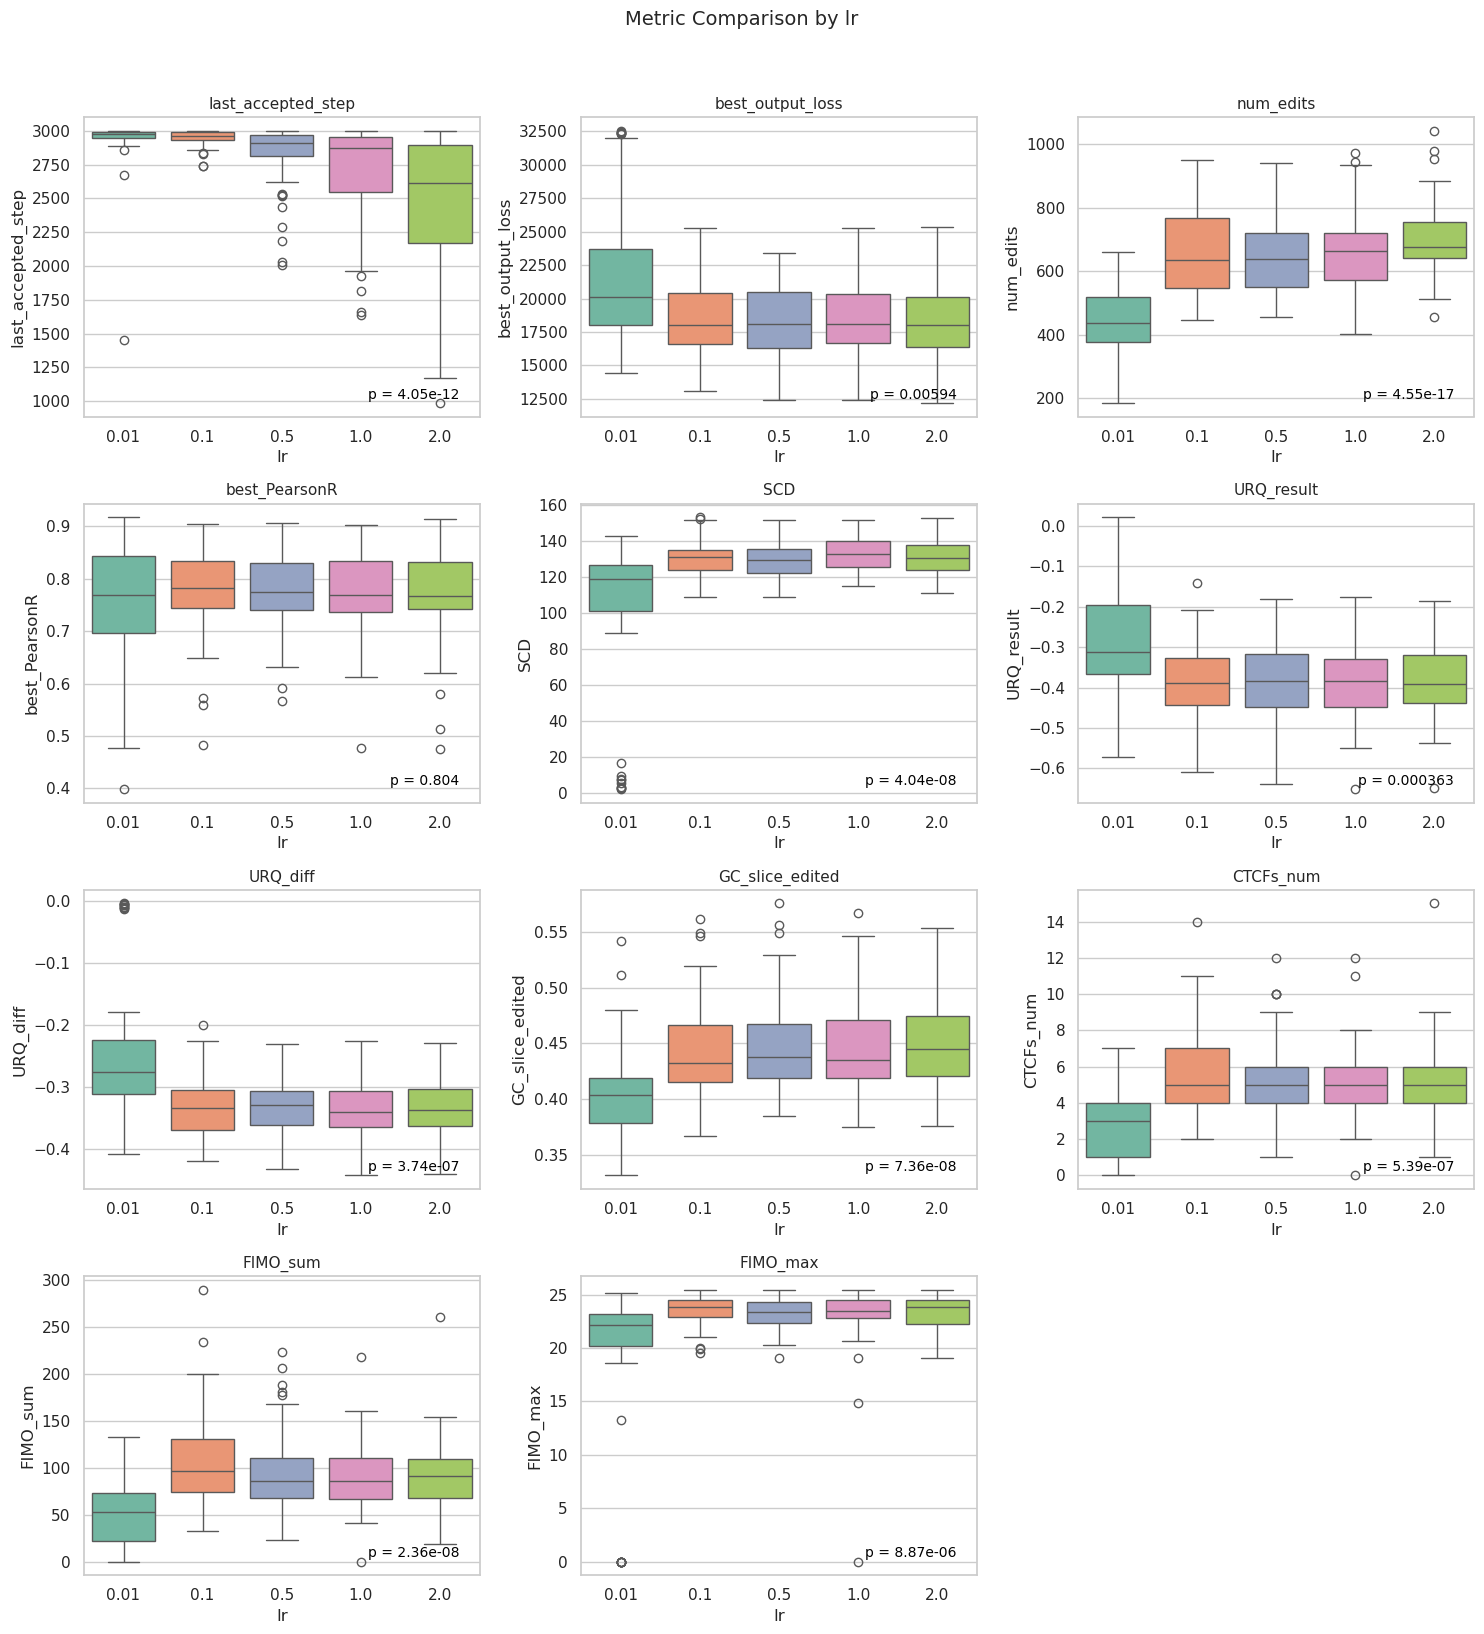

In [11]:
# Define metrics and tau order
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Optional: make sure tau is float
df['lr'] = df['lr'].astype(float)

# Sort tau values for consistent order in plots
lr_order = sorted(df['lr'].unique())

# Set up grid
n_cols = 3
n_rows = -(-len(metrics) // n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='lr', y=metric, ax=ax, palette="Set2", order=lr_order)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("lr")
    ax.set_ylabel(metric)

    # Kruskal-Wallis test across all tau groups
    try:
        groups = [df[df['lr'] == lr][metric].dropna() for lr in lr_order]
        if all(len(g) > 0 for g in groups):
            stat, pval = kruskal(*groups)
            ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='black')
        else:
            ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Metric Comparison by lr", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
